# Classic VRPs

This notebook shows how to use PyVRP to solve two classic variants of the VRP: the capacitated vehicle routing problem (CVRP), and the vehicle routing problem with time windows (VRPTW).
It builds on the tutorial by solving much larger instances, and going into more detail about the various plotting tools and diagnostics available in PyVRP.

A CVRP instance is defined on a complete graph $G=(V,A)$, where $V$ is the vertex set and $A$ is the arc set. 
The vertex set $V$ is partitioned into $V=\{0\} \cup V_c$, where $0$ represents the depot and $V_c=\{1, \dots, n\}$ denotes the set of $n$ customers.
Each arc $(i, j) \in A$ has a weight $d_{ij} \ge 0$ that represents the travel distance from $i \in V$ to $j \in V$.
Each customer $i \in V_c$ has a demand $q_{i} \ge 0$.
The objective is to find a feasible solution that minimises the total distance.

A VRPTW instance additionally incorporates time aspects into the problem.
For the sake of exposition we assume the travel duration $t_{ij} \ge 0$ is equal to the travel distance $d_{ij}$ in this notebook.
Each customer $i \in V_c$ has a service time $s_{i} \ge 0$ and a (hard) time window $\left[e_i, l_i\right]$ that denotes the earliest and latest time that service can start.
A vehicle is allowed to arrive at a customer location before the beginning of the time window, but it must wait for the window to open to start the delivery. 
Each vehicle must return to the depot before the end of the depot time window $H$.
The objective is to find a feasible solution that minimises the total distance.

Let's first import what we will use in this notebook.

In [1]:
import matplotlib.pyplot as plt
from tabulate import tabulate
from vrplib import read_solution

from pyvrp import read, solve
from pyvrp.plotting import (
    plot_coordinates,
    plot_instance,
    plot_result,
    plot_route_schedule,
)
from pyvrp.stop import MaxIterations, MaxRuntime

## The capacitated VRP

### Reading the instance

We will solve the `X-n439-k37` instance, which is part of the [X instance set](http://vrp.atd-lab.inf.puc-rio.br/index.php/en/new-instances) that is widely used to benchmark CVRP algorithms.
The function `pyvrp.read` reads the instance file and converts it to a `ProblemData` instance. 
We pass the argument `round_func="round"` to compute the Euclidean distances rounded to the nearest integral, which is the convention for the X benchmark set.
We also load the best known solution to evaluate our solver later on.

In [2]:
INSTANCE = read("data/X-n439-k37.vrp", round_func="round")
BKS = read_solution("data/X-n439-k37.sol")

Let's plot the instance and see what we have.

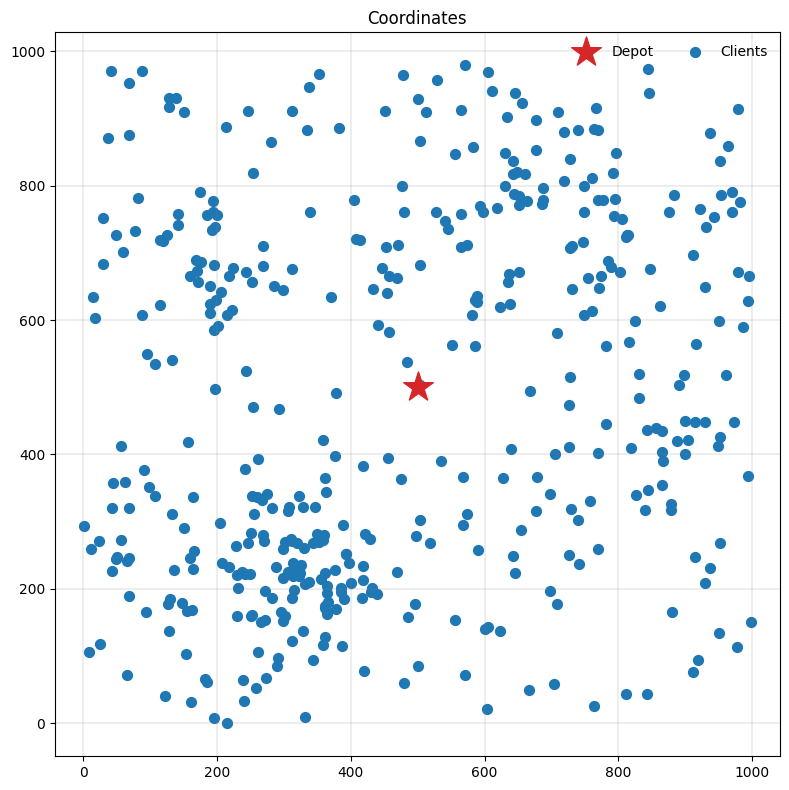

In [3]:
_, ax = plt.subplots(figsize=(8, 8))
plot_coordinates(INSTANCE, ax=ax)
plt.tight_layout()

### Solving the instance

We will use the default `solve` method that PyVRP provides for data instances.

In [4]:
result = solve(INSTANCE, stop=MaxIterations(2000), seed=42, display=False)
print(result)

Solution results
    # routes: 37
     # trips: 37
   # clients: 438
   objective: 37309
    distance: 37309
    duration: 37309
# iterations: 2000
    run-time: 2.55 seconds

Routes
------
Route #1: 180 107 314 306 53 20 111 148 85 12 48
Route #2: 387 287 395 184 390 62 109 90 140 1 176 204
Route #3: 99 77 182 78 256 96 179
Route #4: 298 185 70 104 60 143 147 82 32 434 2 105
Route #5: 207 58 161 361 220 331 330 19 248 430 28 401
Route #6: 231 295 358 238 305 362 187 136 59 236 217 414
Route #7: 129 191 158 29 87 102 127 119 76 201 40 247
Route #8: 44 324 229 420 396 423 391 337 433 377 268 233
Route #9: 283 251 137 98 341 350 286 47 376 138 246 437
Route #10: 165 235 382 174 160 310 222 178 291 313 265 124
Route #11: 199 39 35 405 168 95 52 272 214 198 328 279
Route #12: 155 41 71 72 97 400 299 386 267 410 411 326
Route #13: 128 186 54 27 94 212 46 49 45 277 69 68
Route #14: 154 91 118 173 88 344 7 197 431 144 334 146
Route #15: 55 288 318 294 23 258 93 33 278 226 317 36
Route #16: 30

In [5]:
gap = 100 * (result.cost() - BKS["cost"]) / BKS["cost"]
print(f"Found a solution with cost: {result.cost()}.")
print(f"This is {gap:.1f}% worse than the best known", end=" ")
print(f"solution, which is {BKS['cost']}.")

Found a solution with cost: 37309.
This is 2.5% worse than the best known solution, which is 36391.


We've managed to find a very good solution quickly!

The `Result` object also contains useful statistics about the optimisation.
We can now plot these statistics as well as the final solution use `plot_result`.

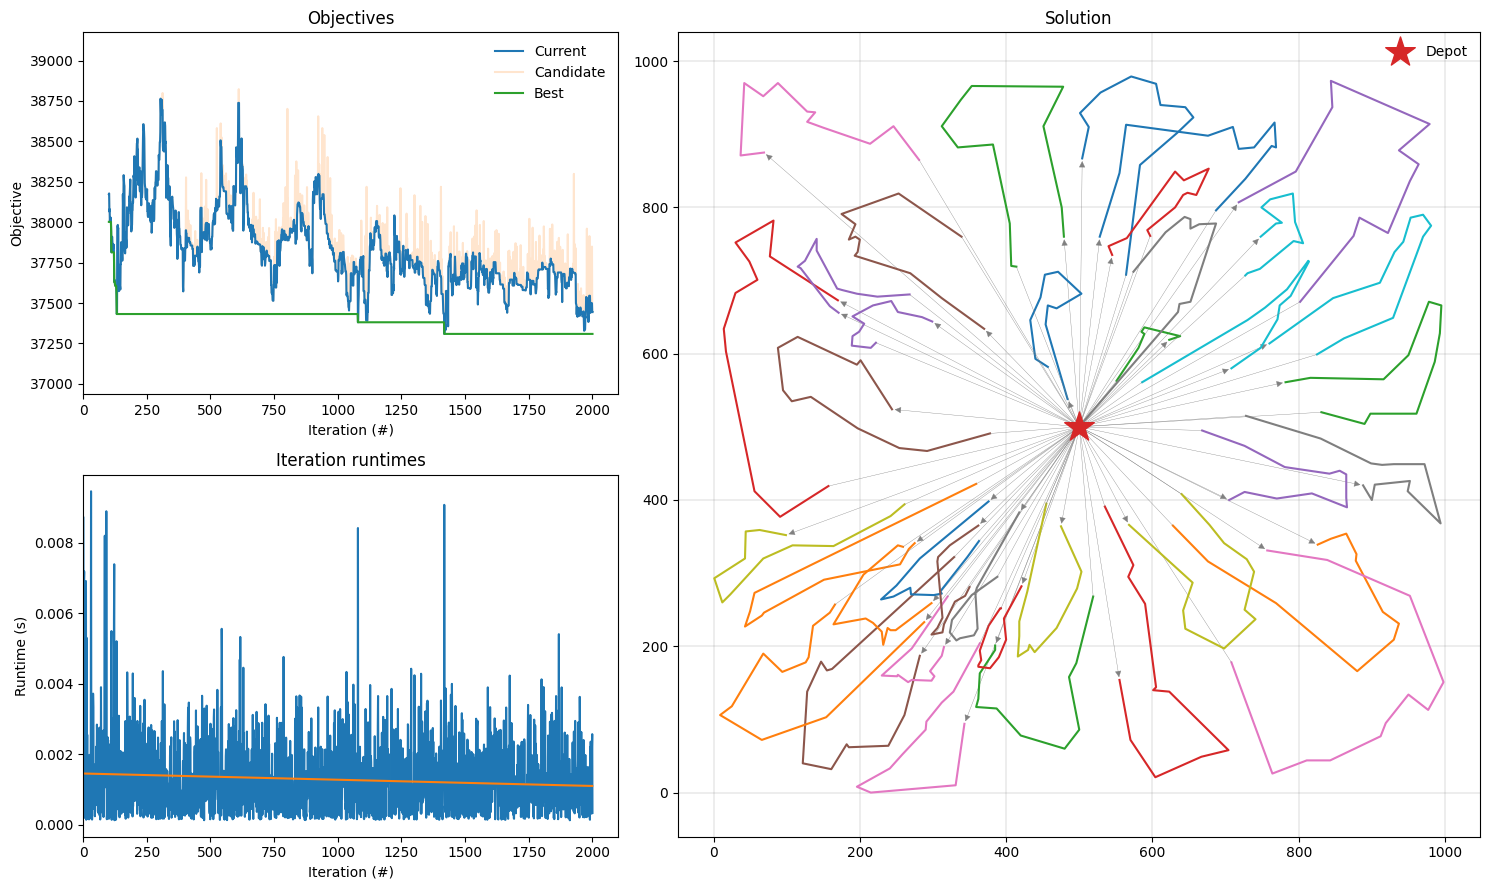

In [6]:
fig = plt.figure(figsize=(15, 9))
plot_result(result, INSTANCE, fig)
fig.tight_layout()

The *Objectives* plot gives an overview of the solution quality over the course of the search.
The bottom-left figure shows iteration runtimes in seconds.
Finally, the *Solution* plot shows the best observed solution.

## The VRP with time windows

### Reading the instance

We start with a basic example that loads an instance and solves it using the standard configuration used by the `solve` method.
For the basic example we use one of the well-known Solomon instances.

We again use the function `pyvrp.read`. We pass the argument `round_func="dimacs"` following the [DIMACS VRP challenge](http://dimacs.rutgers.edu/programs/challenge/vrp/) convention, this computes distances and durations truncated to one decimal place.

In [7]:
INSTANCE = read("data/RC208.vrp", round_func="dimacs")
BKS = read_solution("data/RC208.sol")

Let's plot the instance and see what we have.
The function `plot_instance` will plot time windows, delivery demands and coordinates, which should give us a good impression of what the instance looks like.
These plots can also be produced separately by calling the appropriate `plot_*` function: see [the API documentation](https://pyvrp.readthedocs.io/en/latest/api/plotting.html) for details.

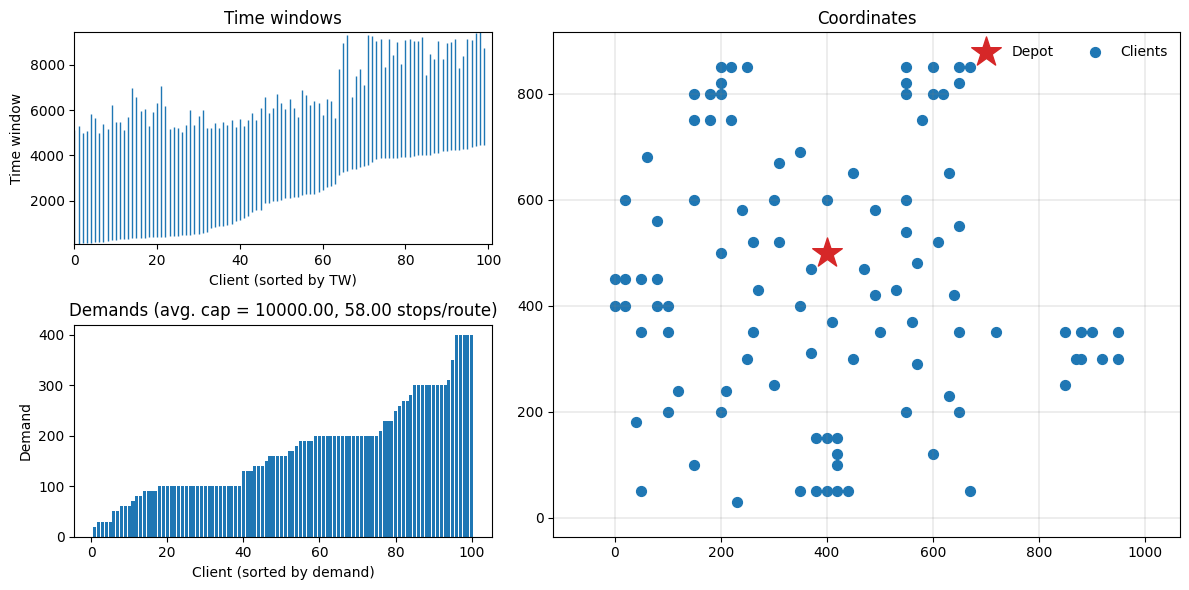

In [8]:
fig = plt.figure(figsize=(12, 6))
plot_instance(INSTANCE, fig)

### Solving the instance

In [9]:
result = solve(INSTANCE, stop=MaxIterations(1000), seed=42, display=False)
print(result)

Solution results
    # routes: 4
     # trips: 4
   # clients: 100
   objective: 7850
    distance: 7850
    duration: 17850
# iterations: 1000
    run-time: 0.59 seconds

Routes
------
Route #1: 90 65 82 99 52 83 64 49 19 18 48 21 23 25 77 58 75 97 59 87 74 86 57 24 22 20 56 66
Route #2: 92 95 62 84 51 85 63 76 89 33 30 32 28 26 27 29 31 34 50 67 94 91 80
Route #3: 61 81 93 71 72 42 44 43 40 36 35 37 38 39 41 54 96
Route #4: 69 98 88 2 6 7 79 73 78 12 14 47 17 16 15 13 9 11 10 53 60 8 46 4 45 5 3 1 70 100 55 68



In [10]:
cost = result.cost() / 10
gap = 100 * (cost - BKS["cost"]) / BKS["cost"]
print(f"Found a solution with cost: {cost}.")
print(f"This is {gap:.1f}% worse than the optimal solution,", end=" ")
print(f"which is {BKS['cost']}.")

Found a solution with cost: 785.0.
This is 1.1% worse than the optimal solution, which is 776.1.


We've managed to find a (near) optimal solution in a few seconds!

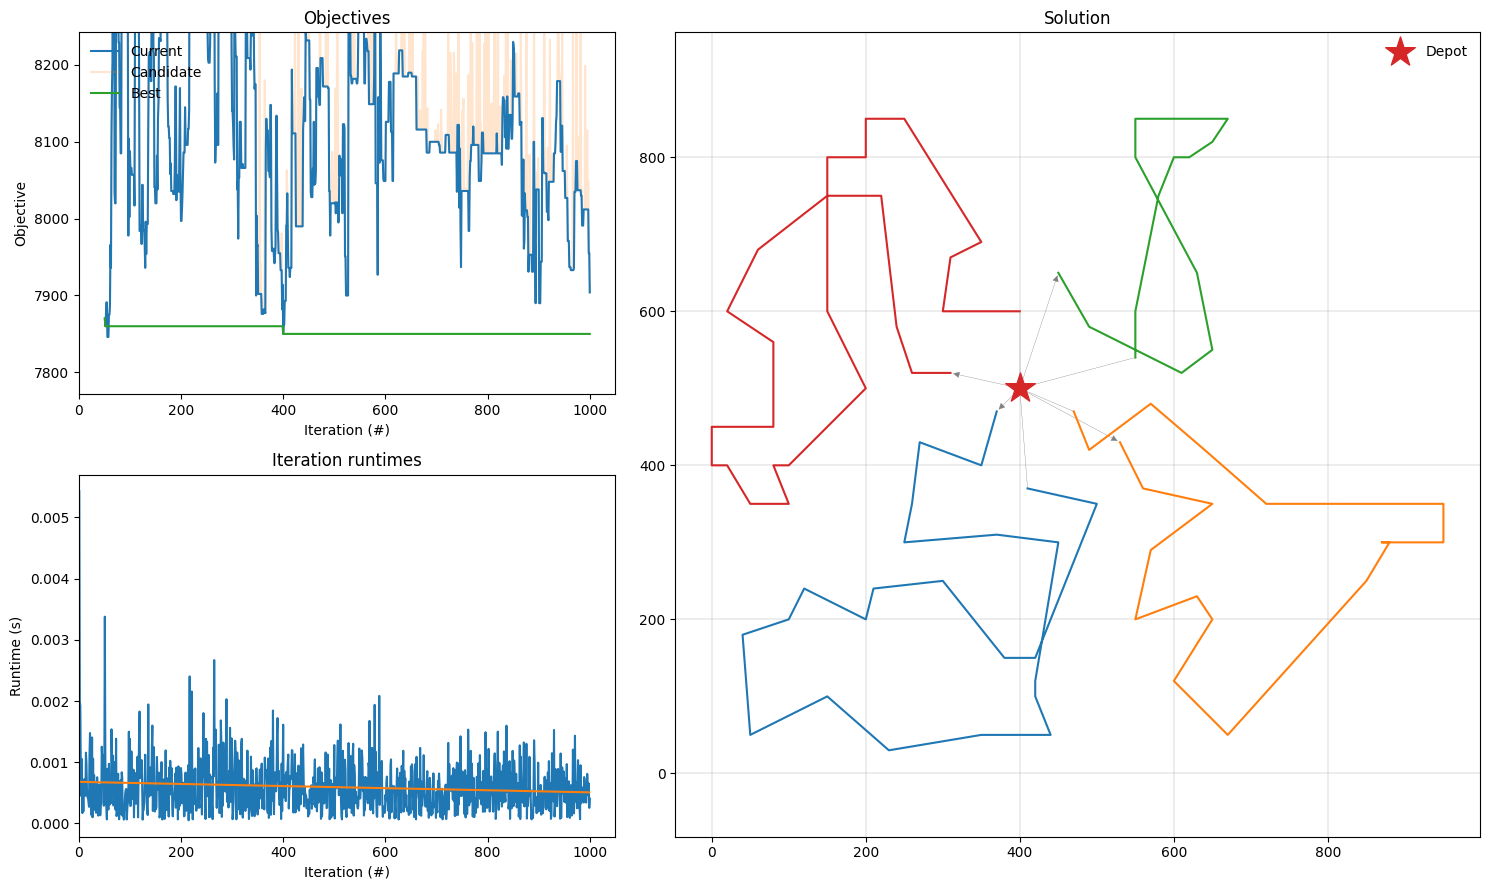

In [11]:
fig = plt.figure(figsize=(15, 9))
plot_result(result, INSTANCE, fig)
fig.tight_layout()

We can also inspect some statistics of the different routes, such as route distance, various durations, the number of stops and total delivery amount.

In [12]:
solution = result.best
routes = solution.routes()

data = [
    {
        "num_stops": len(route),
        "distance": route.distance(),
        "service_duration": route.service_duration(),
        "wait_duration": route.wait_duration(),
        "time_warp": route.time_warp(),
        "delivery": route.delivery(),
    }
    for route in routes
]

tabulate(data, headers="keys", tablefmt="html")

num_stops,distance,service_duration,wait_duration,time_warp,delivery
28,2274,2800,0,0,[4840]
23,1935,2300,0,0,[3620]
17,1375,1700,0,0,[2860]
32,2266,3200,0,0,[5920]


We can inspect the routes in more detail using the `plot_route_schedule` function.
This will plot distance on the x-axis, and time on the y-axis, separating actual travel/driving time from waiting and service time.
The clients visited are plotted as grey vertical bars indicating their time windows.
In some cases, there is slack in the route indicated by a semi-transparent region on top of the earliest time line.
The grey background indicates the remaining load of the truck during the route, where the (right) y-axis ends at the vehicle capacity.

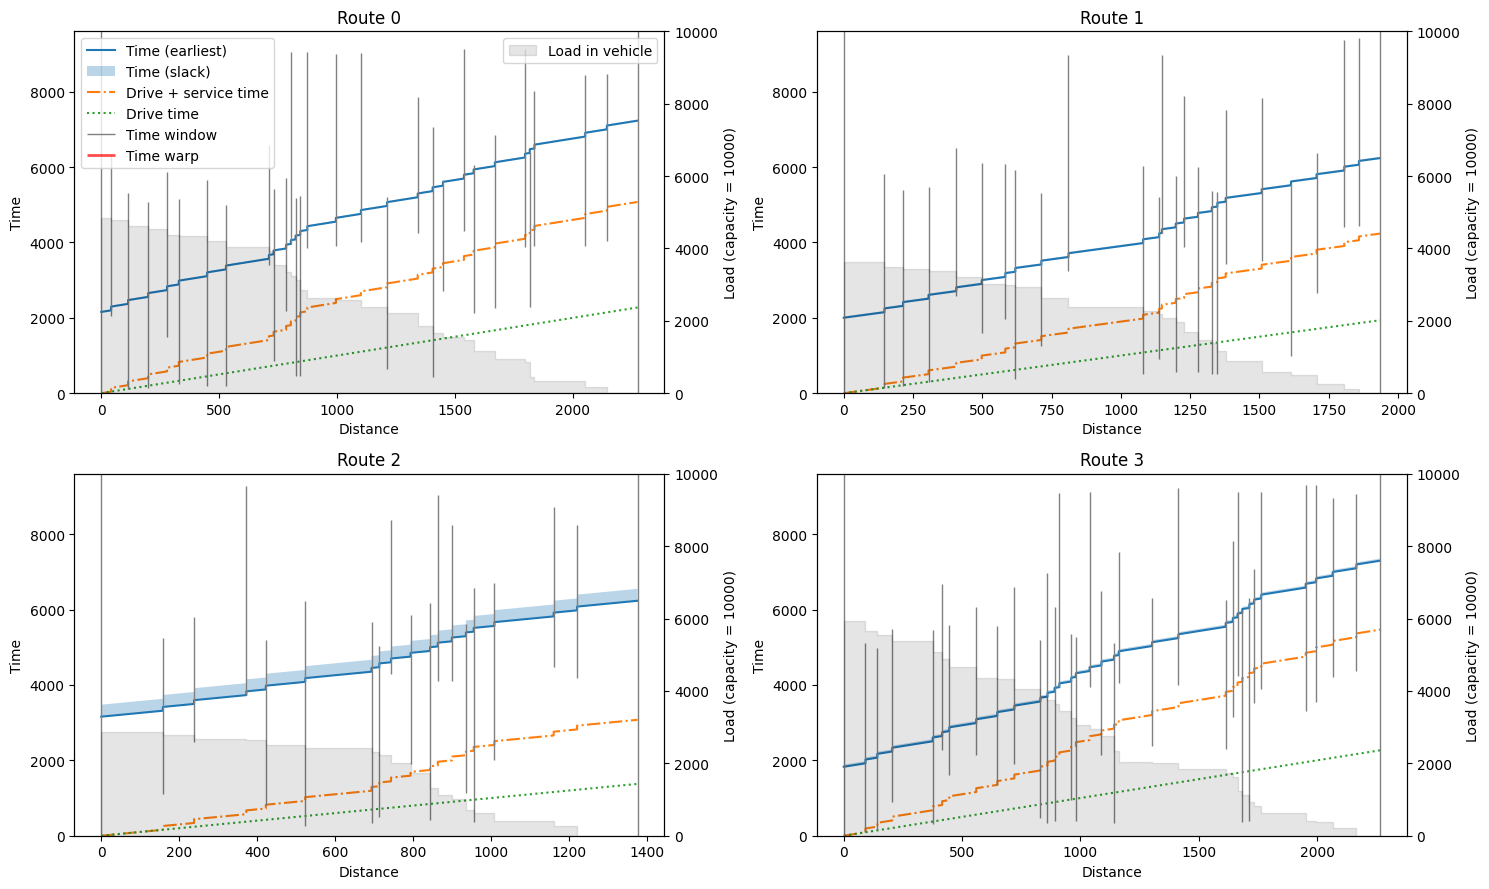

In [13]:
fig, axarr = plt.subplots(2, 2, figsize=(15, 9))
for idx, (ax, route) in enumerate(zip(axarr.flatten(), routes)):
    plot_route_schedule(
        INSTANCE,
        route,
        title=f"Route {idx}",
        ax=ax,
        legend=idx == 0,
    )

fig.tight_layout()

Each route begins at a given `start_time`, that can be obtained as follows.
Note that this start time is typically not zero, that is, routes do not have to start immediately at the beginning of the time horizon.

In [14]:
solution = result.best
shortest_route = min(solution.routes(), key=len)

shortest_route.start_time()

3158

Some of the statistics presented in the plots above can also be obtained from the route schedule, as follows:

In [15]:
data = [
    {
        "location": visit.location,  # Client or depot location of visit
        "start_service": visit.start_service,
        "end_service": visit.end_service,
        "service_duration": visit.service_duration,
        "wait_duration": visit.wait_duration,  # if vehicle arrives early
    }
    for visit in shortest_route.schedule()
]

tabulate(data, headers="keys", tablefmt="html")

location,start_service,end_service,service_duration,wait_duration
0,3158,3158,0,0
61,3316,3416,100,0
81,3496,3596,100,0
93,3730,3830,100,0
71,3880,3980,100,0
72,4081,4181,100,0
42,4351,4451,100,0
44,4471,4571,100,0
43,4601,4701,100,0
40,4751,4851,100,0


## Solving a larger VRPTW instance

To show that PyVRP can also handle much larger instances, we will solve one of the largest Gehring and Homberger VRPTW benchmark instances.
The selected instance - `RC2_10_5` - has 1000 clients.

In [16]:
INSTANCE = read("data/RC2_10_5.vrp", round_func="dimacs")
BKS = read_solution("data/RC2_10_5.sol")

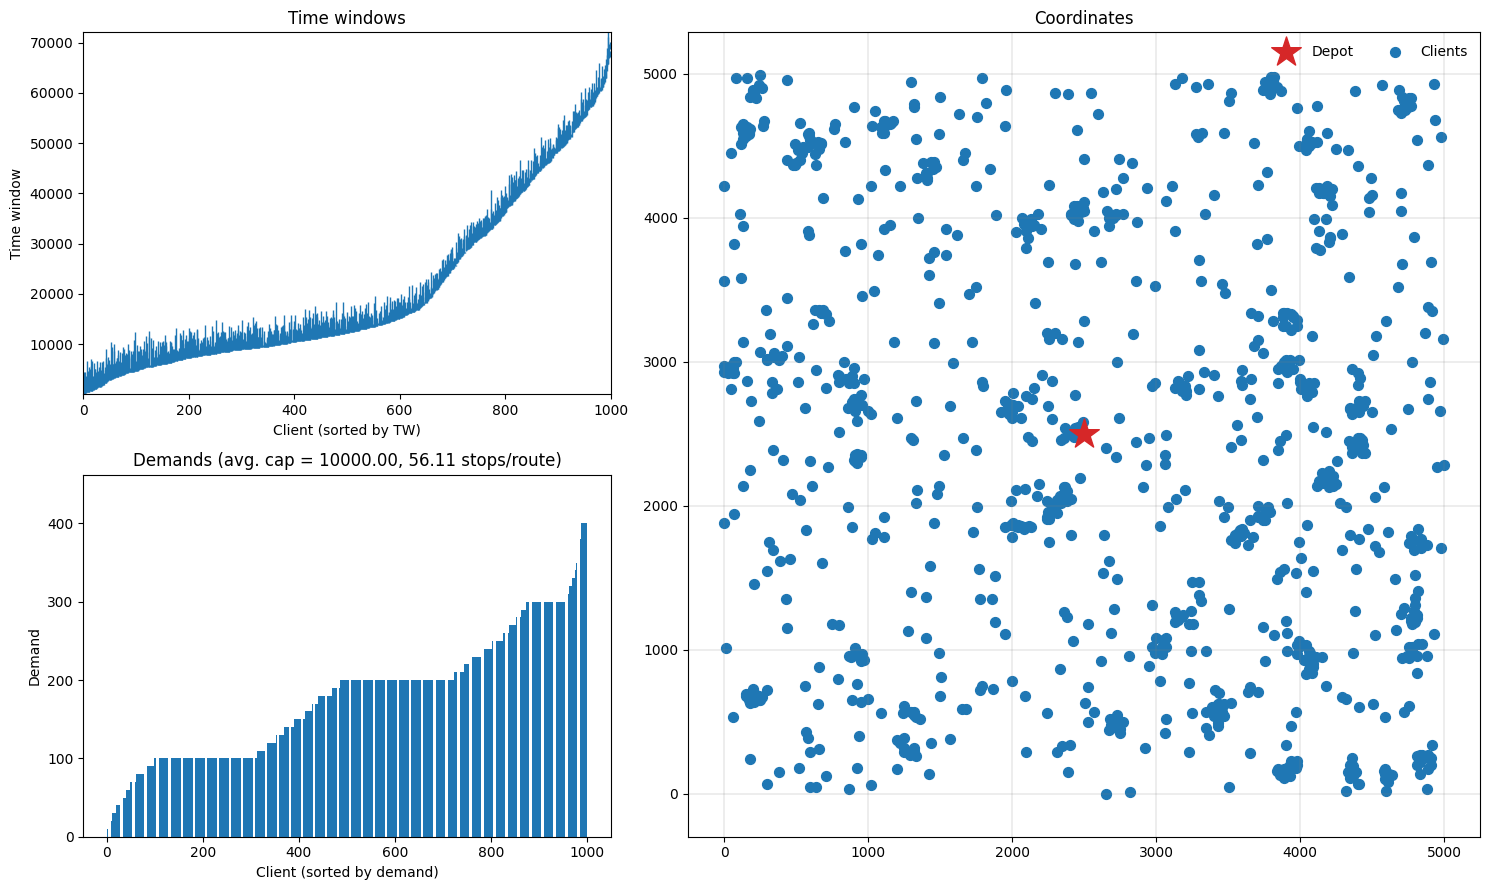

In [17]:
fig = plt.figure(figsize=(15, 9))
plot_instance(INSTANCE, fig)

Here, we will use a runtime-based stopping criterion: we give the solver 30 seconds to compute.

In [18]:
result = solve(INSTANCE, stop=MaxRuntime(30), seed=42, display=False)

In [19]:
cost = result.cost() / 10
gap = 100 * (cost - BKS["cost"]) / BKS["cost"]
print(f"Found a solution with cost: {cost}.")
print(f"This is {gap:.1f}% worse than the best-known solution,", end=" ")
print(f"which is {BKS['cost']}.")

Found a solution with cost: 26154.4.
This is 1.4% worse than the best-known solution, which is 25797.5.


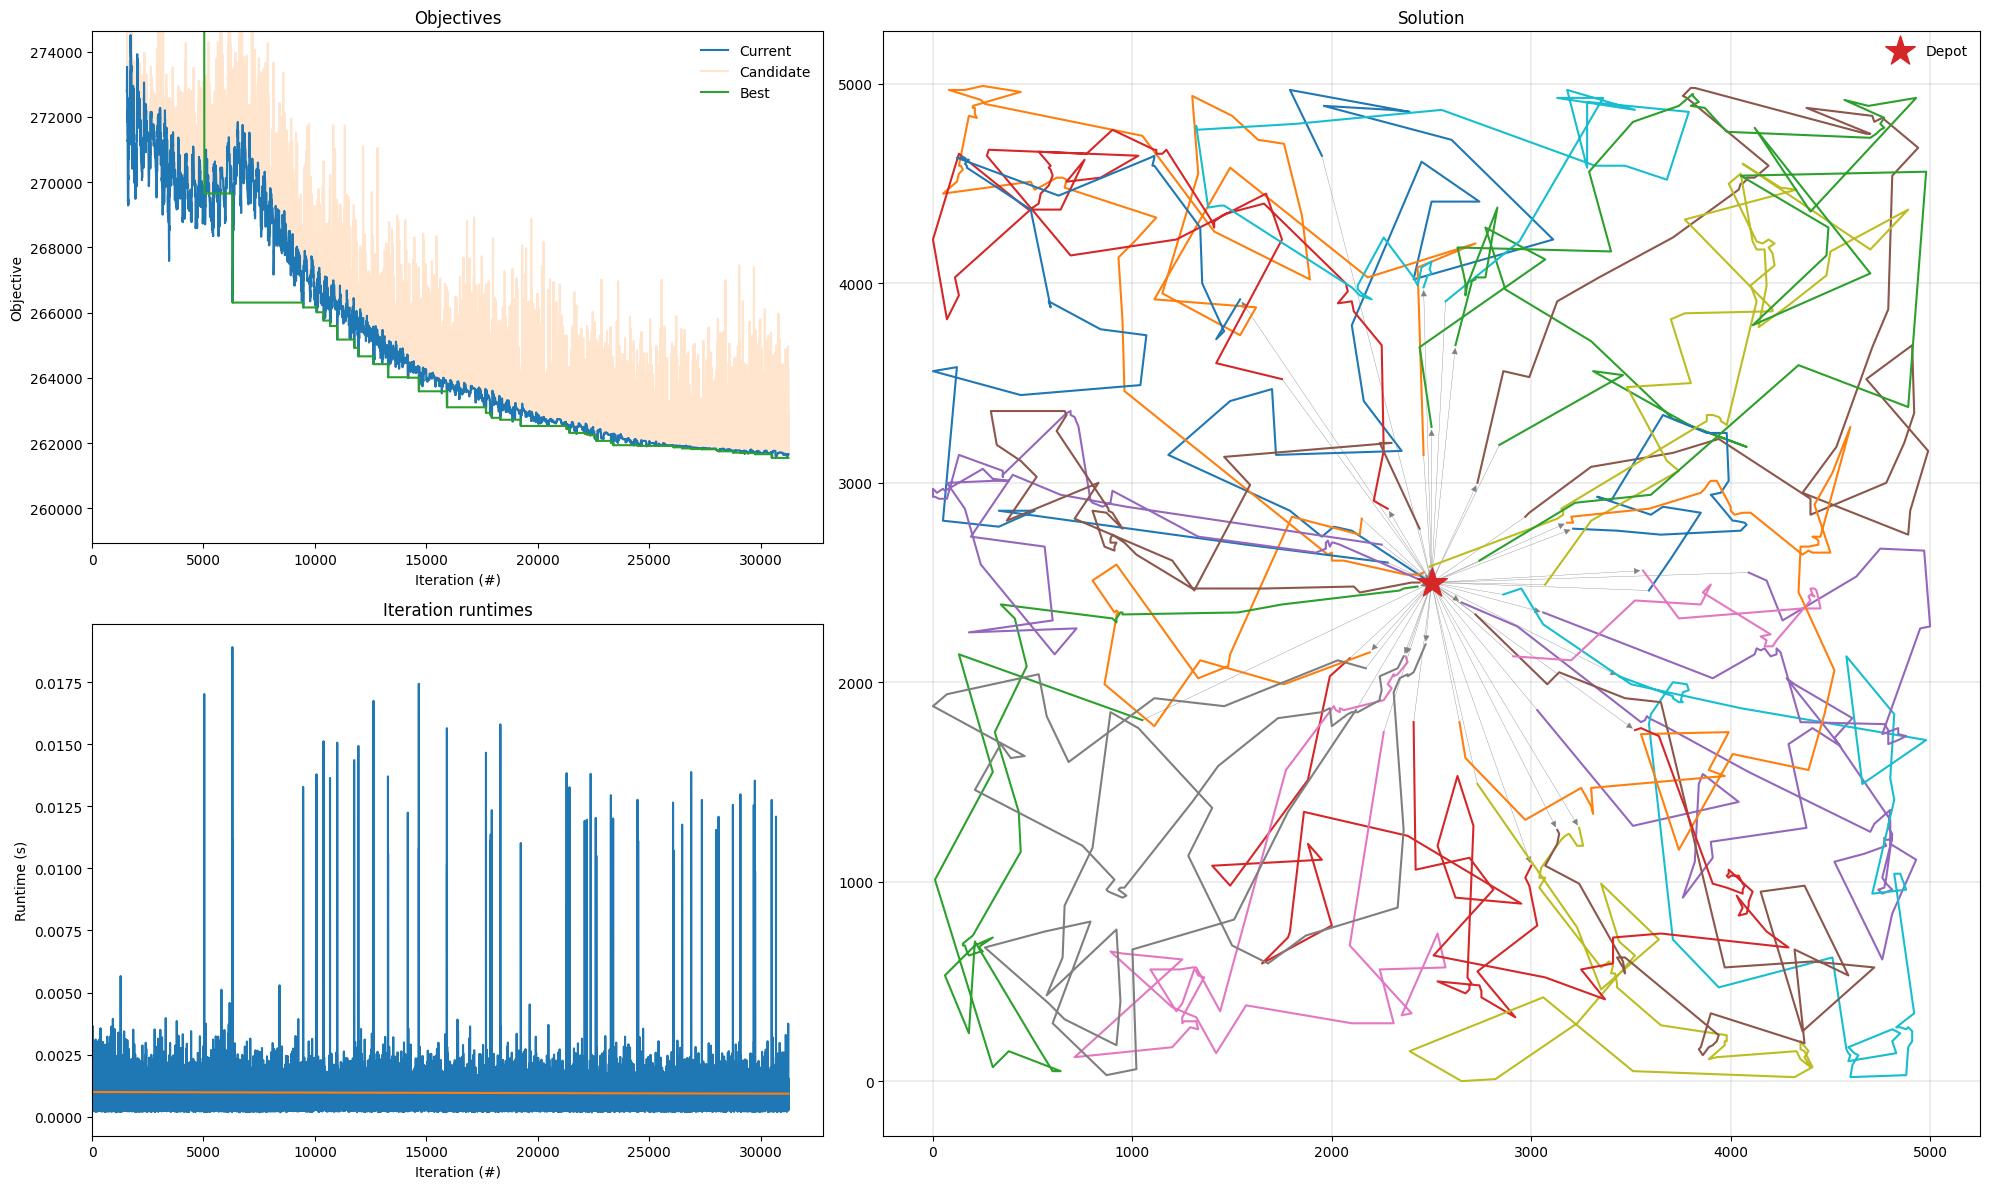

In [20]:
plot_result(result, INSTANCE)
plt.tight_layout()

## Conclusion

In this notebook, we used PyVRP's `solve` functionality to solve a CVRP instance with 438 clients to near-optimality, as well as several VRPTW instances, including a large 1000 client instance.
Moreover, we demonstrated how to use the plotting tools to visualise the instance and statistics collected during the search procedure.